# Graded Response Model — Duckworth Grit Scale (Single Scale)

Fits a single-dimensional GRM to all 12 Grit Scale items.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['TQDM_DISABLE'] = '1'
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from plot_helpers import (plot_loss_comparison, plot_forest_discriminations,
                          plot_ability_scatter, plot_ability_distributions,
                          plot_thresholds, plot_individual_abilities,
                          plot_imputation_weights_pcolormesh)

## 1. Load Data

In [2]:
from bayesianquilts.data.grit import get_data, item_keys, response_cardinality

df, num_people = get_data(polars_out=True)
print(f"Dataset: {num_people} people, {len(item_keys)} items, {response_cardinality} response categories (0-{response_cardinality - 1})")
print(f"Item keys: {item_keys}")
df.head()

Dataset: 4270 people, 12 items, 5 response categories (0-4)
Item keys: ['GS1', 'GS2', 'GS3', 'GS4', 'GS5', 'GS6', 'GS7', 'GS8', 'GS9', 'GS10', 'GS11', 'GS12']


person,GS1,GS2,GS3,GS4,GS5,GS6,GS7,GS8,GS9,GS10,GS11,GS12
u32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,0,0,2,2,2,1,2,0,2,1,2,2
1,1,1,2,2,1,0,2,2,1,0,2,1
2,2,2,2,2,3,2,3,3,2,2,2,2
3,0,2,3,1,3,0,4,3,0,0,2,0
4,0,1,2,2,1,1,1,3,2,2,3,3


In [3]:
SUBSAMPLE_N = num_people
sub_df = df
print(f"Using full dataset: N = {SUBSAMPLE_N}")

Using full dataset: N = 4270


## 2. Prepare Data

In [4]:
def make_data_dict(dataframe):
    data = {}
    for col in dataframe.columns:
        arr = dataframe[col].to_numpy().astype(np.float64)
        data[col] = arr
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

batch = make_data_dict(sub_df)

# Check for missing/invalid values
n_bad = sum(
    np.sum(np.isnan(batch[k]) | (batch[k] < 0) | (batch[k] >= response_cardinality))
    for k in item_keys
)
print(f"Bad/missing values: {n_bad}")

BATCH_SIZE = 256
steps_per_epoch = int(np.ceil(SUBSAMPLE_N / BATCH_SIZE))
print(f"N: {SUBSAMPLE_N}, Batch size: {BATCH_SIZE}, Steps per epoch: {steps_per_epoch}")

def data_factory():
    indices = np.arange(SUBSAMPLE_N)
    np.random.shuffle(indices)
    for start in range(0, SUBSAMPLE_N, BATCH_SIZE):
        end = min(start + BATCH_SIZE, SUBSAMPLE_N)
        idx_batch = indices[start:end]
        yield {k: v[idx_batch] for k, v in batch.items()}

Bad/missing values: 183
N: 4270, Batch size: 256, Steps per epoch: 17


## 3. Fit Baseline GRM (Ignorable Missingness)

In [5]:
from bayesianquilts.irt.grm import GRModel

model_baseline = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    kappa_scale=0.1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
)

NUM_EPOCHS = 200
SNAPSHOT_EPOCH = 50

res_baseline = model_baseline.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    lr_decay_factor=0.975,
    patience=10,
    zero_nan_grads=True,
    snapshot_epoch=SNAPSHOT_EPOCH,
)

losses_baseline = res_baseline[0]
snapshot_params = res_baseline[2] if len(res_baseline) > 2 else None
print(f"Final baseline loss: {losses_baseline[-1]:.2f}")
if snapshot_params is not None:
    print(f"Snapshot saved at epoch {SNAPSHOT_EPOCH}")

--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'eta\\softplus\\normal\\loc', 'eta\\softplus\\normal\\scale', 'kappa\\softplus\\igamma\\concentration', 'kappa\\softplus\\igamma\\scale', 'kappa_a\\softplus\\igamma\\concentration', 'kappa_a\\softplus\\igamma\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/17 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/17 [00:03<?, ?batch/s, best_loss=inf, loss=14257.1192]

Epoch 1/200 (LR: 0.000200):   6%|▌         | 1/17 [00:03<01:01,  3.82s/batch, best_loss=inf, loss=14257.1192]

Epoch 1/200 (LR: 0.000200):   6%|▌         | 1/17 [00:03<01:01,  3.82s/batch, best_loss=inf, loss=14660.3685]

...

Epoch 200/200 (LR: 0.000200):   0%|          | 0/17 [00:00<?, ?batch/s, best_loss=5768.2536, loss=5845.3656]

Epoch 200/200 (LR: 0.000200):   0%|          | 0/17 [00:00<?, ?batch/s, best_loss=5768.2536, loss=5854.6004]

Epoch 200/200 (LR: 0.000200):   0%|          | 0/17 [00:00<?, ?batch/s, best_loss=5768.2536, loss=4009.2884]

  -> New best loss found. Checkpoint saved.                    

--- Training Finished ---


Final baseline loss: 5758.47
Snapshot saved at epoch 50


In [6]:
model_baseline.save_to_disk('grm_baseline')

In [7]:
def calibrate_manually(model, n_samples=32, seed=42):
    try:
        surrogate = model.surrogate_distribution_generator(model.params)
        key = jax.random.PRNGKey(seed)
        samples = surrogate.sample(n_samples, seed=key)
        expectations = {k: jnp.mean(v, axis=0) for k, v in samples.items()}
        model.calibrated_expectations = expectations
        model.surrogate_sample = samples
    except KeyError as e:
        print(f"  Warning: surrogate sampling failed ({e}), using point estimates")
        point_estimates = {}
        for key_name, value in model.params.items():
            parts = key_name.split('\\')
            if len(parts) >= 4:
                param_name = parts[0]
                if parts[-2] == 'normal' and parts[-1] == 'loc':
                    point_estimates[param_name] = value
        model.calibrated_expectations = point_estimates

calibrate_manually(model_baseline, n_samples=32, seed=101)

## 4. Fit MICEBayesianLOO Imputation Model

In [8]:
from bayesianquilts.imputation.mice_loo import MICEBayesianLOO

# Convert to pandas, replacing -1 (missing marker) with NaN
pandas_df = sub_df.select(item_keys).to_pandas()
pandas_df = pandas_df.replace(-1, np.nan)
print(f"Missing values per item:\n{pandas_df.isna().sum()}")

mice_loo = MICEBayesianLOO(
    random_state=42,
    prior_scale=1.0,
    pathfinder_num_samples=100,
    pathfinder_maxiter=50,
    batch_size=512,
    verbose=True,
)

mice_loo.fit_loo_models(
    pandas_df,
    n_top_features=12,
    n_jobs=1,
    fit_zero_predictors=True,
    seed=42,
)

Missing values per item:
GS1     10
GS2     14
GS3     12
GS4     34
GS5     11
GS6     14
GS7     14
GS8     10
GS9      9
GS10    15
GS11    15
GS12    25
dtype: int64
Computing feature correlations...
Fitting MICE Bayesian LOO-CV models with Pathfinder
  Variables: 12
  Observations: 4270
  Min obs per model: 5
  Parallel jobs: 1
  Top features per target: 12
  Global Ordinal Values: [0. 1. 2. 3. 4.] (n=5)

Fitting zero-predictor models...
  Scheduling 12 zero-predictor jobs...


  Var 0 (GS1): n_obs=4260, elpd/n=-0.1579


  Var 1 (GS2): n_obs=4256, elpd/n=-0.1790


  Var 2 (GS3): n_obs=4258, elpd/n=-0.1841


  Var 3 (GS4): n_obs=4236, elpd/n=-0.1846


...

  Processing GS8 (11 valid predictors)


  Processing GS9 (11 valid predictors)


  Processing GS10 (11 valid predictors)


  Processing GS11 (11 valid predictors)


  Processing GS12 (11 valid predictors)


In [9]:
mice_loo.save('mice_loo_model.yaml')

In [10]:
from bayesianquilts.imputation.mixed import IrtMixedImputationModel

mixed_imputation = IrtMixedImputationModel(
    irt_model=model_baseline,
    mice_model=mice_loo,
    data_factory=data_factory,
    irt_elpd_batch_size=4,
)

print(mixed_imputation.summary())

Item Weights (MICE vs IRT):
Item           w_mice  ELPD_mice   ELPD_irt
--------------------------------------------
GS1             0.853    -0.1450    -1.9015
GS2             0.800    -0.1583    -1.5456
GS3             0.862    -0.1702    -2.0026
GS4             0.869    -0.1773    -2.0662
GS5             0.847    -0.1695    -1.8804
GS6             0.828     0.0495    -1.5241
GS7             0.872    -0.1607    -2.0824
GS8             0.888    -0.1639    -2.2326
GS9             0.866    -0.1555    -2.0206
GS10            0.839    -0.1695    -1.8180
GS11            0.860    -0.1648    -1.9806
GS12            0.867     0.0400    -1.8316


## 5. Fit GRM with Analytic Rao-Blackwellized Imputation

In [11]:
model_imputed = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    kappa_scale=0.1,
    response_cardinality=response_cardinality,
    imputation_model=mixed_imputation,
    dtype=jnp.float64,
)

if snapshot_params is not None:
    print(f"Warm-starting from baseline epoch-{SNAPSHOT_EPOCH} snapshot")

res_imputed = model_imputed.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    lr_decay_factor=0.975,
    patience=10,
    zero_nan_grads=True,
    initial_values=snapshot_params,
)

losses_imputed = res_imputed[0]
print(f"Final imputed loss: {losses_imputed[-1]:.2f}")

Warm-starting from baseline epoch-50 snapshot
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'eta\\softplus\\normal\\loc', 'eta\\softplus\\normal\\scale', 'kappa\\softplus\\igamma\\concentration', 'kappa\\softplus\\igamma\\scale', 'kappa_a\\softplus\\igamma\\concentration', 'kappa_a\\softplus\\igamma\\scale', 'mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/17 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/17 [00:01<?, ?batch/s, best_loss=inf, loss=8709.5676]

Epoch 1/200 (LR: 0.000200):   6%|▌         | 1/17 [00:01<00:31,  1.97s/batch, best_loss=inf, loss=8709.5676]

Epoch 1/200 (LR: 0.000200):   6%|▌         | 1/17 [00:01<00:31,  1.97s/batch, best_loss=inf, loss=9104.8569]

...

Epoch 200/200 (LR: 0.000200):   0%|          | 0/17 [00:00<?, ?batch/s, best_loss=4972.9438, loss=5014.9194]

Epoch 200/200 (LR: 0.000200):   0%|          | 0/17 [00:00<?, ?batch/s, best_loss=4972.9438, loss=5006.5830]

Epoch 200/200 (LR: 0.000200):   0%|          | 0/17 [00:00<?, ?batch/s, best_loss=4972.9438, loss=3473.4906]

  -> New best loss found. Checkpoint saved.                    

--- Training Finished ---


Final imputed loss: 4967.81


In [12]:
model_imputed.save_to_disk('grm_imputed')

## 6. Compare Results

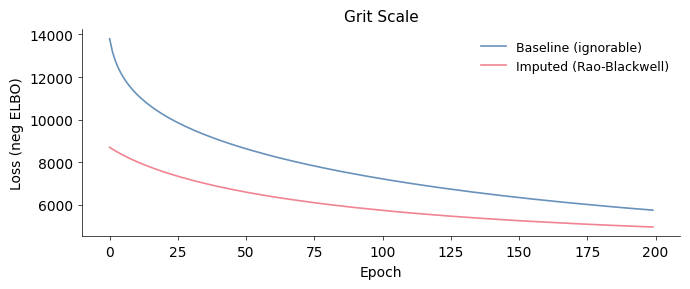

In [13]:
fig = plot_loss_comparison(losses_baseline, losses_imputed, title='Grit Scale')
fig.savefig('loss_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [14]:
calibrate_manually(model_imputed, n_samples=32, seed=102)

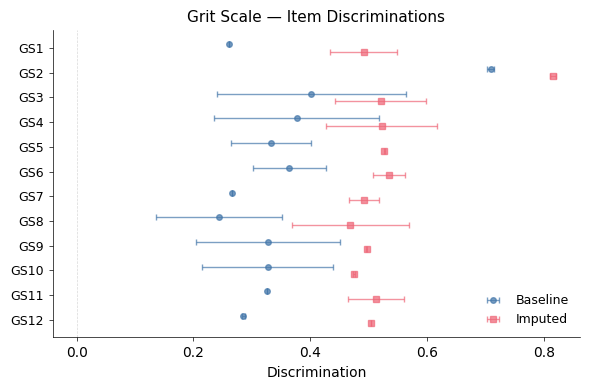

In [15]:
fig = plot_forest_discriminations(item_keys, model_baseline, model_imputed,
                                   title='Grit Scale — Item Discriminations')
fig.savefig('discriminations.pdf', bbox_inches='tight', dpi=150)
plt.show()

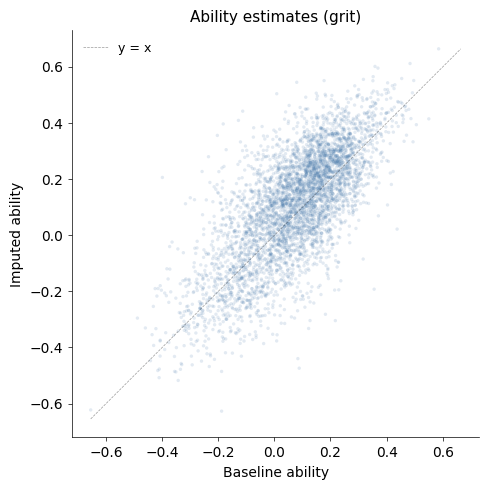

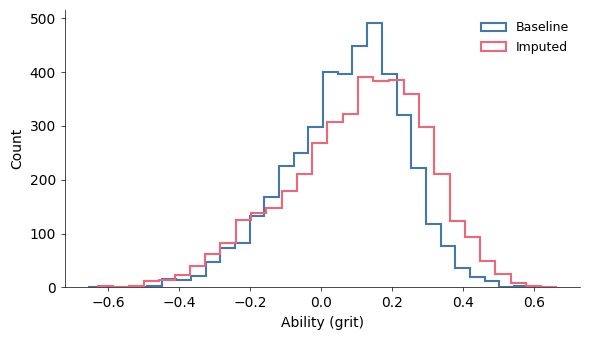

In [16]:
ab_base = np.array(model_baseline.calibrated_expectations['abilities']).flatten()
ab_imp = np.array(model_imputed.calibrated_expectations['abilities']).flatten()

fig = plot_ability_scatter(ab_base, ab_imp, label='grit')
fig.savefig('ability_scatter.pdf', bbox_inches='tight', dpi=150)
plt.show()

fig = plot_ability_distributions(ab_base, ab_imp, label='grit')
fig.savefig('ability_distributions.pdf', bbox_inches='tight', dpi=150)
plt.show()

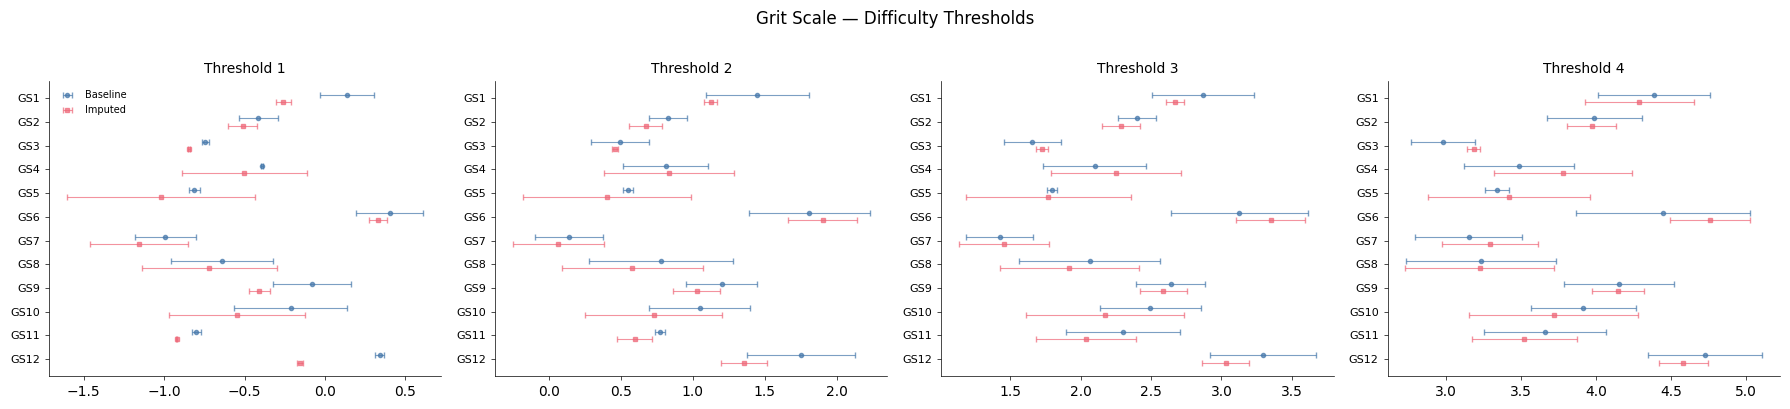

In [17]:
fig = plot_thresholds(item_keys, model_baseline, model_imputed,
                       title='Grit Scale — Difficulty Thresholds')
fig.savefig('thresholds.pdf', bbox_inches='tight', dpi=150)
plt.show()

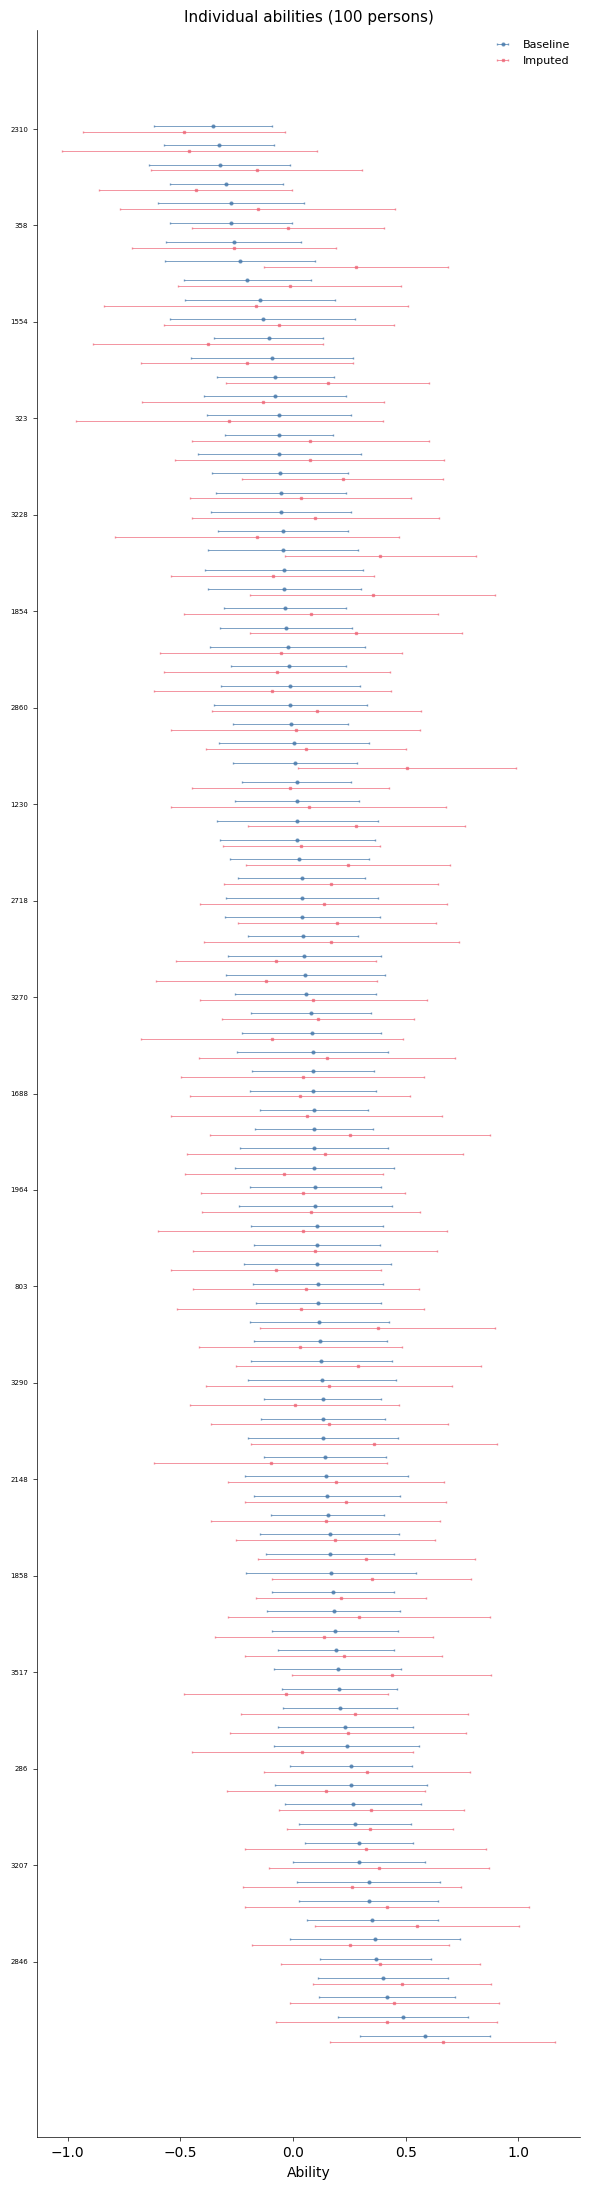

In [18]:
fig = plot_individual_abilities(item_keys, model_baseline, model_imputed)
fig.savefig('individual_abilities.pdf', bbox_inches='tight', dpi=150)
plt.show()

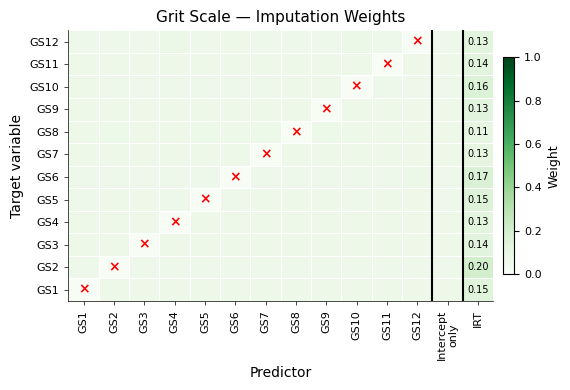

In [19]:
fig = plot_imputation_weights_pcolormesh(mice_loo, mixed_imputation, item_keys,
                                          title='Grit Scale — Imputation Weights')
fig.savefig('imputation_weights.pdf', bbox_inches='tight', dpi=150)
plt.show()

## Summary

This notebook demonstrated fitting a single-scale Graded Response Model to
all 12 Duckworth Grit Scale items (GS1--GS12) with 5 response categories (0--4).

Two models were compared:

1. **Baseline GRM** -- treats missing responses as ignorable (zeroes out their
   log-likelihood contribution).
2. **Imputed GRM** -- uses a **mixed imputation model** that blends
   MICEBayesianLOO (pairwise Bayesian stacking) with the baseline IRT model's
   marginalized predictions. Per-item weights are computed via softmax over
   ELPD scores: `PMF = w_mice × MICE + (1 − w_mice) × IRT_baseline`.
   Missing cells are handled via analytic Rao-Blackwellization.

The discrimination parameters indicate how well each item differentiates
respondents along the single Grit dimension. Comparing the two models
shows the effect of explicitly modelling missingness on parameter estimates.